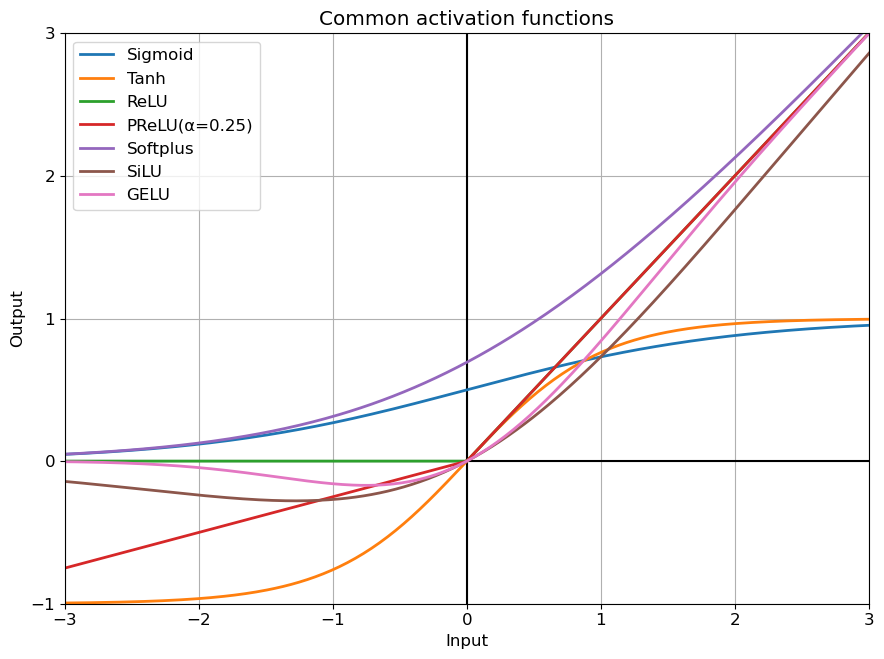

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf

scale = 1.5
xlim = (-3, 3)
ylim = (-1, 3)
# ==========================
# Matplotlib 配置
# ==========================
plt.rcParams["figure.figsize"] = (6 * scale, 4.5 * scale)  # 设置图像大小
plt.rcParams["font.size"] = 12
# plt.rcParams["axes.grid"] = True

# ==========================
# 数据
# ==========================
x = np.linspace(-10, 10, 1000)


# ==========================
# 激活函数
# ==========================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return np.tanh(x)


def relu(x):
    return np.maximum(0, x)


def leaky_relu(x, alpha=0.1):
    return np.where(x >= 0, x, alpha * x)


def prelu(x, alpha=0.25):
    return np.where(x >= 0, x, alpha * x)


def elu(x, alpha=1.0):
    return np.where(x >= 0, x, alpha * (np.exp(x) - 1))


def softplus(x):
    return np.log1p(np.exp(x))


def silu(x):
    return x * sigmoid(x)


def gelu(x):
    erf_vec = np.vectorize(erf)
    return 0.5 * x * (1 + erf_vec(x / np.sqrt(2)))


# ==========================
# 绘图
# ==========================
plt.figure()

# 坐标轴
plt.axhline(0, color="black")
plt.axvline(0, color="black")
plt.plot(x, sigmoid(x), linewidth=2, label="Sigmoid")
plt.plot(x, tanh(x), linewidth=2, label="Tanh")
# plt.plot(x, leaky_relu(x), linewidth=2, label="Leaky ReLU(α=0.1)")
plt.plot(x, relu(x), linewidth=2, label="ReLU")
plt.plot(x, prelu(x), linewidth=2, label="PReLU(α=0.25)")
# plt.plot(x, elu(x), linewidth=2, label="ELU(α=1.0)")
plt.plot(x, softplus(x), linewidth=2, label="Softplus")
plt.plot(x, silu(x), linewidth=2, label="SiLU")
plt.plot(x, gelu(x), linewidth=2, label="GELU")


plt.xlim(xlim)
plt.ylim(ylim)
plt.xticks(np.arange(round(xlim[0]), round(xlim[1]) + 1, 1))
plt.yticks(np.arange(round(ylim[0]), round(ylim[1]) + 1, 1))

plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Common activation functions")

# 图例放右侧，避免遮挡曲线
plt.legend(loc="best", frameon=True)

plt.tight_layout()

# 保存高清图片
plt.savefig("activation_functions.png", dpi=600, bbox_inches="tight")

plt.show()